# Treasury market according to Flow of Funds Data

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dbnomics import fetch_series

In [2]:
# Paramétrage des styles utilisés par matplotlib
plt.style.use('default')
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

### Premiers graphiques

Code :
* Le .Q à la fin c'est pour donnée Quaterly (et.A pour annuelle).
* FL : pour les niveaux
* Secteur c'est les deux chiffres suivants
* 30611 c'est pour l'instrument (Treasuries)
* 05 pour les "computed series"

Code pour le moment :
* FL143061105.Q : Nonfinancial business (S11) 
* FL153061105.Q : Households and nonprofit organizations (S14+S15)
* FL263061105.Q : Rest of the World (S2)*
* FL383061105.Q : Domestic nonfinancial sectors
* FL403061105.Q : Government-sponsored enterprises (GSEs)
* FL473061105.Q : Credit Unions
* FL513061105.Q : Property-casualty insurance companies*
* FL523061105.Q : Insurance companies (S128)
* FL533061105.Q : Closed-end and exchange-traded funds
* FL543061105.Q : Life insurance companies*
* FL573061105.Q : Private pension funds
* FL583061105.Q : Insurance companies and pension funds (S128+S129) 
* FL593061105.Q : Pension funds (S129)
* FL603061105.Q : Other financial intermediaries except insurance companies, pension funds, financial auxiliaries and captive financial institutions and money lenders (S125)
* FL803061105.Q : Other financial intermediaries except insurance companies and pension funds (S125+S126+S127) 
* FL633061105.Q : Money market funds (S123)
* FL653061105.Q : Mutual funds*
* FL663061105.Q : Security brokers and dealers (S127 ?)
* FL693061105.Q : Non-MMF investment funds (S124)
* FL703061105.Q : Private depository institutions (S122)
* FL713061125.Q : Monetary authority (S121)
* FL783061105.Q : Private depository institutions and money market funds (S122+S123)
* FL793061105.Q : Domestic financial sectors (S12)
* FL893061105.Q : All sectors


codes = {
    "Nonfinancial business (S11)": "FL143061105.Q",
    "Rest of World (S2)": "FL263061105.Q",
    "Households (S14+S15)": "FL153061105.Q",
    "Monetary authority (S121)": "FL713061125.Q",
    "Private Depository Institutions (S122)": "FL703061105.Q",
    "Money Market Funds (S123)": "FL633061105.Q",
    "Mutual Funds (S124)": "FL653061105.Q",
    "Other financial intermediaries except insurance companies and pension funds (S125+S126+S127)" : "FL803061105.Q",
    "Insurance companies (S128)": "FL523061105.Q",
    "Pension Funds (S129)": "FL593061105.Q"
}

\* petite incertitude pcq y'a trois séries possibles sur dbnmics, probablement une erreur

In [10]:
dim = {"SERIES_INSTRUMENT": ["30611"]}

df = fetch_series("FED", "Z1", dimensions = dim, max_nb_series=2)

In [ ]:
import dbnomics
import pandas as pd
import matplotlib.pyplot as plt

# Sélection des séries (sans double comptage)
codes = {
    "Nonfinancial business (S11)": "FL143061105.Q",
    "Rest of World (S2)": "FL263061105.Q",
    "Households and non-profit organizations (S14+S15)": "FL153061105.Q",
    "Monetary authority (S121)": "FL713061125.Q",
    "Private Depository Institutions (S122)": "FL703061105.Q",
    "Money Market Funds (S123)": "FL633061105.Q",
    "Mutual Funds (S124)": "FL653061105.Q",
    "Other financial intermediaries except insurance companies and pension funds (S125+S126+S127)" : "FL803061105.Q",
    "Insurance companies (S128)": "FL523061105.Q",
    "Pension Funds (S129)": "FL593061105.Q",
    "Security brokers and dealers": "FL663061105.Q",
    "Closed-end and exchange-traded funds": "FL533061105.Q"
}

# Télécharger et assembler les séries
dfs = []
for label, code in codes.items():
    data = dbnomics.fetch_series(f"FED/Z1/{code}")
    df_temp = data[['period', 'value']].dropna()
    df_temp['period'] = pd.PeriodIndex(df_temp['period'], freq='Q').to_timestamp()
    df_temp = df_temp.set_index('period').rename(columns={'value': label})
    dfs.append(df_temp)

df = pd.concat(dfs, axis=1)

# Télécharger la série "All sectors"
all_sectors = dbnomics.fetch_series("FED/Z1/FL893061105.Q")
all_sectors = all_sectors[['period', 'value']].dropna()
all_sectors['period'] = pd.PeriodIndex(all_sectors['period'], freq='Q').to_timestamp()
all_sectors = all_sectors.set_index('period')['value']

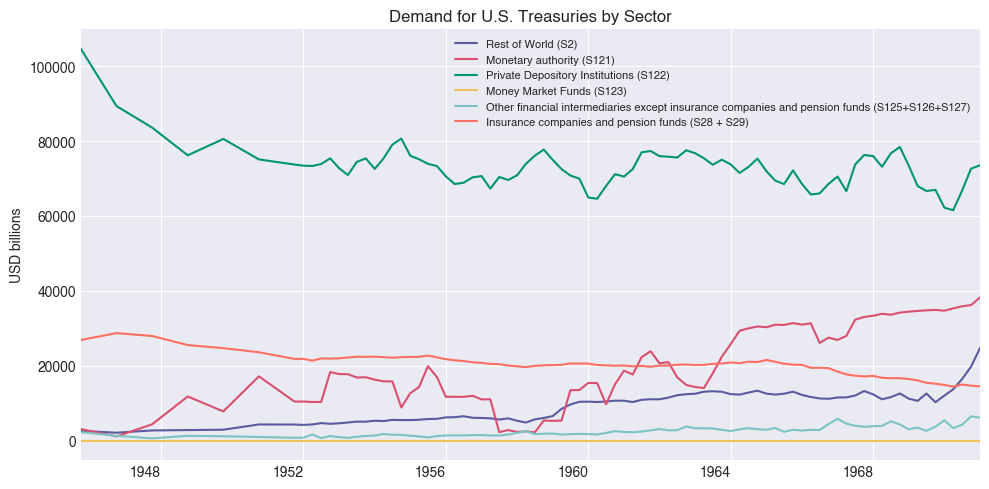

In [47]:
df1 = df.copy()
df1["Insurance companies and pension funds (S28 + S29)"] = df1["Insurance companies (S128)"] + df1["Pension Funds (S129)"]

df1 = df1.drop(columns=["Households and non-profit organizations (S14+S15)", "Mutual Funds (S124)", "Nonfinancial business (S11)", "Insurance companies (S128)", "Pension Funds (S129)"])
df1.index.name = None

start_date = '1945-01-01'
end_date = '1971-01-01'
df1 = df1[(df.index >= start_date) & (df.index <= end_date)]

# Tracer
fig, ax = plt.subplots(figsize=(10, 5))
df1.plot(ax=ax)
ax.set_title("Demand for U.S. Treasuries by Sector")
ax.set_ylabel("USD billions")
#ax.set_yscale('log')
#ax.set_yscale('symlog', linthresh=10000)
ax.grid(True)
ax.set_xmargin(0)
plt.xticks(rotation=0)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
print(df.columns.tolist())

['Nonfinancial business (S11)', 'Rest of World (S2)', 'Households and non-profit organizations (S14+S15)', 'Monetary authority (S121)', 'Private Depository Institutions (S122)', 'Money Market Funds (S123)', 'Mutual Funds (S124)', 'Other financial intermediaries except insurance companies and pension funds (S125+S126+S127)', 'Insurance companies (S128)', 'Pension Funds (S129)']


In [28]:
df1.head()

,Rest of World (S2),Monetary authority (S121),Private Depository Institutions (S122),Money Market Funds (S123),Other financial intermediaries except insurance companies and pension funds (S125+S126+S127),Insurance companies (S128),Pension Funds (S129)
period,,,,,,,
1945-10-01,2574.0,3067.0,104606.0,0.0,2232.0,23289.0,3570.0
1946-10-01,2100.0,1109.0,89339.0,0.0,1273.0,24929.0,3771.0
1947-10-01,2700.0,4329.0,83598.0,0.0,587.0,23925.0,4011.0
1948-10-01,2800.0,11768.0,76192.0,0.0,1273.0,21225.0,4273.0
1949-10-01,2900.0,7781.0,80562.0,0.0,1153.0,20124.0,4557.0
